<a href="https://colab.research.google.com/github/manishashivarathri2004-ctrl/cloud-kitchen-crm/blob/main/Copy_of_finalheartdiseaseprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow flask pyngrok scikit-learn pandas numpy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from flask import Flask, request, render_template_string
from pyngrok import ngrok
import os

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

--2025-10-19 15:35:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘processed.cleveland.data’

processed.cleveland     [ <=>                ]  18.03K  --.-KB/s    in 0.06s   

2025-10-19 15:35:14 (305 KB/s) - ‘processed.cleveland.data’ saved [18461]



In [ ]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
df = pd.read_csv('processed.cleveland.data', names=column_names)
print(df.head())  # View first 5 rows
print(df.info())  # Check data types and missing values

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  num  
0    3.0  0.0  6.0    0  
1    2.0  3.0  3.0    2  
2    2.0  2.0  7.0    1  
3    3.0  0.0  3.0    0  
4    1.0  0.0  3.0    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5 

In [ ]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.astype(float)  # Convert to float

In [ ]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('num', axis=1)
y = df['num']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
    layers.Dropout(0.2),  # Prevent overfitting
    layers.Dense(32, activation='relu'),  # Hidden layer
    layers.Dense(1, activation='sigmoid')  # Output: 0 or 1
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4623 - loss: 0.7238 - val_accuracy: 0.6042 - val_loss: 0.6739
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7328 - loss: 0.6040 - val_accuracy: 0.6667 - val_loss: 0.6113
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7912 - loss: 0.5203 - val_accuracy: 0.7500 - val_loss: 0.5663
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7501 - loss: 0.5076 - val_accuracy: 0.7500 - val_loss: 0.5325
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8058 - loss: 0.4420 - val_accuracy: 0.8125 - val_loss: 0.5050
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8712 - loss: 0.4100 - val_accuracy: 0.8125 - val_loss: 0.4926
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8117 - loss: 0.4080 - val_accuracy: 0.8125 - val_loss: 0.4922
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8501 - loss: 0.3861 - val_accuracy: 0.7917 - val_loss

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       0.91      0.88      0.89        24

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60



In [ ]:
model.save('heart_model.h5')

In [ ]:
from flask import Flask, request, render_template_string
from pyngrok import ngrok
import threading  # For running Flask in a thread

# Recompile the model to suppress the warning (optional but recommended)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

app = Flask(__name__)

# HTML for input page (now professional and colorful)
input_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>CVD Risk Predictor</title>
    <style>
        body { font-family: Arial, sans-serif; background: linear-gradient(to bottom, #e3f2fd, #ffffff); margin: 0; padding: 20px; color: #333; }
        .container { max-width: 600px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #1976d2; margin-bottom: 20px; }
        form { display: flex; flex-direction: column; }
        label { margin-bottom: 5px; font-weight: bold; color: #424242; }
        input { padding: 10px; margin-bottom: 15px; border: 1px solid #ccc; border-radius: 5px; font-size: 16px; }
        input[type="submit"] { background: #4caf50; color: white; border: none; cursor: pointer; font-size: 18px; padding: 12px; border-radius: 5px; transition: background 0.3s; }
        input[type="submit"]:hover { background: #388e3c; }
        footer { text-align: center; margin-top: 20px; font-size: 14px; color: #666; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🫀 Cardiovascular Disease Risk Predictor</h1>
        <p style="text-align: center; color: #666;">Enter patient details below to assess CVD risk. This tool is for educational purposes only—consult a healthcare professional for advice.</p>
        <form action="/predict" method="post">
            <label for="age">Age:</label>
            <input type="number" id="age" name="age" placeholder="e.g., 50" required>

            <label for="sex">Sex (0=Female, 1=Male):</label>
            <input type="number" id="sex" name="sex" placeholder="0 or 1" required>

            <label for="cp">Chest Pain Type (0-3):</label>
            <input type="number" id="cp" name="cp" placeholder="0-3" required>

            <label for="trestbps">Resting Blood Pressure:</label>
            <input type="number" id="trestbps" name="trestbps" placeholder="e.g., 120" required>

            <label for="chol">Cholesterol:</label>
            <input type="number" id="chol" name="chol" placeholder="e.g., 200" required>

            <label for="fbs">Fasting Blood Sugar (0=No, 1=Yes):</label>
            <input type="number" id="fbs" name="fbs" placeholder="0 or 1" required>

            <label for="restecg">Resting ECG (0-2):</label>
            <input type="number" id="restecg" name="restecg" placeholder="0-2" required>

            <label for="thalach">Max Heart Rate:</label>
            <input type="number" id="thalach" name="thalach" placeholder="e.g., 150" required>

            <label for="exang">Exercise Angina (0=No, 1=Yes):</label>
            <input type="number" id="exang" name="exang" placeholder="0 or 1" required>

            <label for="oldpeak">Oldpeak:</label>
            <input type="number" id="oldpeak" name="oldpeak" placeholder="e.g., 1.0" step="0.1" required>

            <label for="slope">Slope (0-2):</label>
            <input type="number" id="slope" name="slope" placeholder="0-2" required>

            <label for="ca">CA (0-3):</label>
            <input type="number" id="ca" name="ca" placeholder="0-3" required>

            <label for="thal">Thal (0-2):</label>
            <input type="number" id="thal" name="thal" placeholder="0-2" required>

            <input type="submit" value="Predict Risk">
        </form>
        <footer>© 2023 CVD Predictor | Educational Tool</footer>
    </div>
</body>
</html>
"""

# HTML for output page (now professional, colorful, with suggestions and stats)
output_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Prediction Result</title>
    <style>
        body { font-family: Arial, sans-serif; background: linear-gradient(to bottom, #e8f5e8, #ffffff); margin: 0; padding: 20px; color: #333; }
        .container { max-width: 700px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #1976d2; margin-bottom: 20px; }
        .result { text-align: center; font-size: 24px; font-weight: bold; margin: 20px 0; padding: 15px; border-radius: 5px; }
        .high-risk { background: #ffebee; color: #d32f2f; border: 1px solid #d32f2f; }
        .low-risk { background: #e8f5e8; color: #388e3c; border: 1px solid #388e3c; }
        .stats { background: #f3e5f5; padding: 15px; border-radius: 5px; margin: 20px 0; }
        .suggestions { background: #e3f2fd; padding: 15px; border-radius: 5px; margin: 20px 0; }
        ul { list-style-type: disc; margin-left: 20px; }
        a { display: inline-block; margin-top: 20px; padding: 10px 20px; background: #1976d2; color: white; text-decoration: none; border-radius: 5px; transition: background 0.3s; }
        a:hover { background: #1565c0; }
        footer { text-align: center; margin-top: 20px; font-size: 14px; color: #666; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🫀 CVD Risk Prediction Result</h1>
        <div class="result {{ 'high-risk' if 'High' in result else 'low-risk' }}">
            {{ '⚠️ ' if 'High' in result else '✅ ' }}{{ result }}
        </div>

        <div class="stats">
            <h3>📊 General Statistics</h3>
            <p>Cardiovascular disease (CVD) is a leading cause of death worldwide. According to the World Health Organization (WHO), CVD affects approximately 17.9 million people annually, accounting for 31% of all global deaths. Risk factors include high blood pressure, cholesterol, and lifestyle habits.</p>
        </div>

        <div class="suggestions">
            <h3>💡 Suggestions and Precautions</h3>
            {% if 'High' in result %}
                <p><strong>Since your risk is high, take immediate action:</strong></p>
                <ul>
                    <li>Consult a cardiologist or healthcare provider for a thorough check-up and personalized advice.</li>
                    <li>Monitor and manage blood pressure, cholesterol, and blood sugar levels regularly.</li>
                    <li>Adopt a heart-healthy diet: Reduce salt, saturated fats, and processed foods; increase fruits, vegetables, and whole grains.</li>
                    <li>Engage in regular physical activity: Aim for at least 150 minutes of moderate exercise per week (e.g., brisk walking).</li>
                    <li>Avoid smoking and limit alcohol intake.</li>
                    <li>Track symptoms like chest pain or shortness of breath and seek emergency care if needed.</li>
                </ul>
            {% else %}
                <p><strong>Your risk is low—maintain it with these habits:</strong></p>
                <ul>
                    <li>Schedule annual check-ups to monitor heart health.</li>
                    <li>Eat a balanced diet rich in nutrients and maintain a healthy weight.</li>
                    <li>Stay active: Incorporate daily exercise to keep your heart strong.</li>
                    <li>Avoid risk factors like smoking and excessive stress.</li>
                    <li>Stay informed: Learn about heart health through reliable sources like the American Heart Association.</li>
                </ul>
            {% endif %}
            <p><em>Note: This is general guidance. Always consult a doctor for medical advice.</em></p>
        </div>

        <a href="/">Predict Again</a>
        <footer>© 2023 CVD Predictor | Educational Tool</footer>
    </div>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(input_html)

@app.route('/predict', methods=['POST'])
def predict():
    # Get form data
    data = [float(request.form[key]) for key in ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']]
    data_scaled = scaler.transform([data])  # Scale the input
    prediction = model.predict(data_scaled)[0][0]
    result = "High Risk of CVD" if prediction > 0.5 else "Low Risk of CVD"
    return render_template_string(output_html, result=result)

# Function to run Flask in a thread
def run_app():
    app.run(port=5000, debug=False, use_reloader=False)  # Disable debug/reloader for Colab

# Start ngrok tunnel
ngrok.set_auth_token('YOUR_NGROK_AUTH_TOKEN')  # Replace with your actual ngrok auth token (get it from ngrok.com)
public_url = ngrok.connect(5000)
print("Public URL:", public_url)  # This will print the link to access the app

# Run Flask in a background thread
thread = threading.Thread(target=run_app)
thread.start()

print("Flask app is running in the background. You can now use other cells or access the public URL.")


Public URL: NgrokTunnel: "https://palaeontographic-erwin-addable.ngrok-free.dev" -> "http://localhost:5000"
Flask app is running in the background. You can now use other cells or access the public URL.
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score
y_pred_prob = model.predict(X_test)  # Get probabilities
y_pred = (y_pred_prob > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Confusion Matrix:
 [[34  2]
 [ 3 21]]
ROC-AUC Score: 0.9456018518518519


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)
# Retrain the model with augmented data
model.fit(X_train_aug, y_train_aug, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9022 - loss: 0.2464 - val_accuracy: 0.8600 - val_loss: 0.4252
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9402 - loss: 0.1725 - val_accuracy: 0.8400 - val_loss: 0.4309
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9275 - loss: 0.2707 - val_accuracy: 0.8400 - val_loss: 0.4330
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9201 - loss: 0.2562 - val_accuracy: 0.8400 - val_loss: 0.4458
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9467 - loss: 0.1951 - val_accuracy: 0.8400 - val_loss: 0.4501
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9377 - loss: 0.2229 - val_accuracy: 0.8400 - val_loss: 0.4482
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.1650 - val_accuracy: 0.8400 - val_loss: 0.4505
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9332 - loss: 0.1596 - val_accuracy: 0.8400 - val_los

In [ ]:
# Reshape for CNN (add a dimension for "time steps")
X_train_reshaped = X_train_aug.reshape(X_train_aug.shape[0], X_train_aug.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

model = keras.Sequential([
    layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_reshaped, y_train_aug, epochs=50, batch_size=16, validation_split=0.2)
# Save and update the web app to use this new model
model.save('cvd_model_hybrid.h5')

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4972 - loss: 0.6957 - val_accuracy: 0.6000 - val_loss: 0.6861
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6554 - loss: 0.6797 - val_accuracy: 0.6200 - val_loss: 0.6778
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6882 - loss: 0.6678 - val_accuracy: 0.6200 - val_loss: 0.6675
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6434 - loss: 0.6572 - val_accuracy: 0.6200 - val_loss: 0.6568
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6578 - loss: 0.6445 - val_accuracy: 0.6400 - val_loss: 0.6456
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7082 - loss: 0.6066 - val_accuracy: 0.6600 - val_loss: 0.6435
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7337 - loss: 0.6008 - val_accuracy: 0.6600 - val_loss: 0.6332
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7119 - loss: 0.6391 - val_accuracy: 0.6800 - val_loss: 0.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


  0%|          | 0/5 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
16074/16074 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
16074/16074 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
16074/16074 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
16074/16074 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
16074/16074 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step


/tmp/ipython-input-1016743406.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_reshaped[:5].squeeze(), feature_names=column_names[:-1])
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


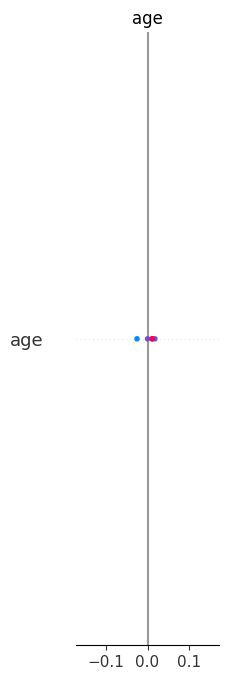

In [ ]:
import shap
import numpy as np

# Use KernelExplainer which is more suitable for deep learning models
# Wrap model.predict in a lambda function to reshape input to 3D
explainer = shap.KernelExplainer(lambda x: model.predict(np.expand_dims(x, axis=-1)), X_train_reshaped.squeeze())

# Calculate SHAP values for the first 5 test samples
# Remove the extra dimension from X_test_reshaped[:5] before passing to explainer
shap_values = explainer.shap_values(X_test_reshaped[:5].squeeze())

# Reshape shap_values for plotting if necessary (depending on model output shape)
# Assuming a single output for binary classification, shap_values will be a list of arrays.
# We need to take the values corresponding to the positive class (index 1)
if isinstance(shap_values, list):
    shap_values = shap_values[0] # Or shap_values[1] if the model outputs probabilities for both classes

# shap_values should already have the correct shape after squeezing the input to explainer.shap_values
# No need to squeeze shap_values again here.

shap.summary_plot(shap_values, X_test_reshaped[:5].squeeze(), feature_names=column_names[:-1])